<a href="https://colab.research.google.com/github/vivek-kothekar/Disease-Outbreak-Prediction-ML-TAE/blob/main/models/roshan_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
----- KNN Results (70-30) -----
Accuracy: 0.6883116883116883
Precision: 0.5487804878048781
Recall: 0.5625
F1 Score: 0.5555555555555556


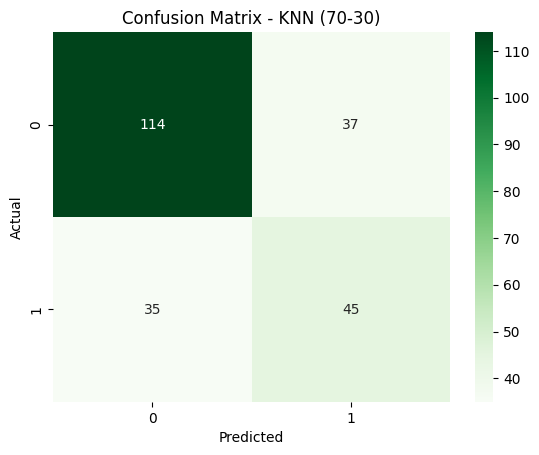

              precision    recall  f1-score   support

           0       0.77      0.75      0.76       151
           1       0.55      0.56      0.56        80

    accuracy                           0.69       231
   macro avg       0.66      0.66      0.66       231
weighted avg       0.69      0.69      0.69       231

----- KNN Results (80-20) -----
Accuracy: 0.6623376623376623
Precision: 0.5245901639344263
Recall: 0.5818181818181818
F1 Score: 0.5517241379310345


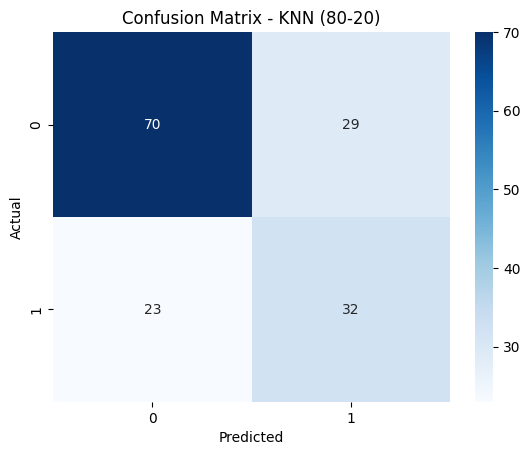

              precision    recall  f1-score   support

           0       0.75      0.71      0.73        99
           1       0.52      0.58      0.55        55

    accuracy                           0.66       154
   macro avg       0.64      0.64      0.64       154
weighted avg       0.67      0.66      0.67       154



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

# Load dataset
df = pd.read_csv("/content/sample_data/diabetes.csv")

# Display first 5 rows
print(df.head())

# Separate features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# -------------------- 70-30 SPLIT --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create KNN model (K = 5)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train model
knn_model.fit(X_train, y_train)

# Predict
y_pred = knn_model.predict(X_test)

# Evaluation
print("----- KNN Results (70-30) -----")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - KNN (70-30)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred))


# -------------------- 80-20 SPLIT --------------------
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
knn_model_80 = KNeighborsClassifier(n_neighbors=5)
knn_model_80.fit(X_train_80, y_train_80)

# Predict
y_pred_80 = knn_model_80.predict(X_test_80)

# Evaluation
print("----- KNN Results (80-20) -----")
print("Accuracy:", accuracy_score(y_test_80, y_pred_80))
print("Precision:", precision_score(y_test_80, y_pred_80))
print("Recall:", recall_score(y_test_80, y_pred_80))
print("F1 Score:", f1_score(y_test_80, y_pred_80))

# Confusion Matrix
cm_80 = confusion_matrix(y_test_80, y_pred_80)
sns.heatmap(cm_80, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - KNN (80-20)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test_80, y_pred_80))